## Lojistik Regresyon (Model)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import scale 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, log_loss
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from warnings import filterwarnings
filterwarnings('ignore')

*Veri seti ve ilgileneceğimiz problem: Diyabet hastalarına ait insülin, glukoz, yaş, kan basıncı, vücut kitle endeksi, geçirdiği hamilelik sayısı gibi bilgilerin tutulduğu bir veri setimiz var. Hedefimiz: Yeni bir hasta geldiğinde o hastanın potansiyel bir şeker hastası olup olmama durumunu tahmin edebilecek bir makine öğrenmesi modeli geliştirmek olacak.*

In [2]:
diabetes = pd.read_csv('diabetes.csv')
df = diabetes.copy()
df = df.dropna()
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

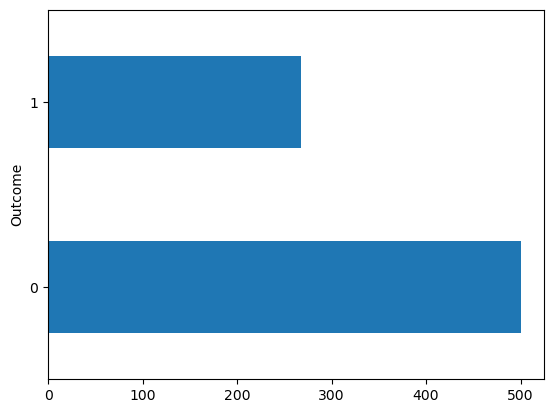

In [5]:
df['Outcome'].value_counts().plot.barh();

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [7]:
y = df['Outcome']
X = df.drop(['Outcome'], axis = 1)

In [8]:
#statsmodels ile model kurulumu

In [9]:
loj = sm.Logit(y, X)
loj_model = loj.fit()

Optimization terminated successfully.
         Current function value: 0.608498
         Iterations 5


In [10]:
loj_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      760
Method:                           MLE   Df Model:                            7
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                 0.05922
Time:                        18:45:34   Log-Likelihood:                -467.33
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 2.583e-10
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Pregnancies                  0.1284      0.029      4.484      0.000       0.072       0.185
Glucose                      0.0129      0.003      4.757      0.000       0.008       0.018
BloodPressure               -0.0303      0.005     -6.481      0.000      -0.039      -0.021
SkinThickness                0.0002      0.006      0.032      0.974      -0.012       0.012
Insulin                      0.0007      0.001      0.942      0.346      -0.001       0.002
BMI                         -0.0048      0.011     -0.449      0.653      -0.026       0.016
DiabetesPedigreeFunction     0.3203      0.240      1.335      0.182      -0.150       0.790
Age                         -0.0156      0.008     -1.852      0.064      -0.032       0.001
============================================================================================
"""

In [11]:
#scikit-learn ile model kurulumu

In [12]:
loj = LogisticRegression(solver = 'liblinear')
loj_model = loj.fit(X, y)

In [13]:
loj_model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'liblinear',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [14]:
loj_model.intercept_

array([-5.84073324])

In [15]:
loj_model.coef_

array([[ 1.16937119e-01,  2.82506791e-02, -1.69647463e-02,
         7.64900753e-04, -6.30568264e-04,  5.91967766e-02,
         6.68475894e-01,  7.08845329e-03]])

## Tahmin & Model Tuning

*Lojistik Regresyon'da diğer algoritmalarda olduğu gibi ele alabileceğimiz bir dışsal parametre (hyperparamter) olmadığından tam olarak burada tuning işlemi yapmayacağız. Burada optimize edilebilecek bir parametre olarak değerlendirebileceğimiz bir parametre var o da sabit. Bu bölümde model doğrulama işlemi gerçekleştireceğiz.*

*Tahmin ve Model Tuning işlemlerine başlamadan önce pınıflandırma problemlerinde sıkça karşılaşılan bir durumdan bahsetmek gerekir.*

*Sınıflandırma problemlerinde ele aldığımız bağımlı değişkenin ilgilendiğimiz sınıfın doğru olup olmadığını kontrol etmek gerekir. Bizim tarafımızdan veya bir şekilde verinin oluşturulması, hazırlanması itibariyle ilgilenilen sınıfın ne olduğunu karıştırabilme durumu söz konusudur. Örneğin şeker hastalığına sahip olup olmama durumunda şeker hastalığına sahip olma durumu, kanserli olup olmama durumunda kanserli olma durumu, kredi kartı borcunu ödeyip ödeyememe durumunda ödeyememe durumu... Bunlar genelde 1.sınıf olur. Bu yüzden dönüştürme işlemleri vs gibi işlemlerde bu durumların kontrol edilmesi elzemdir. Yanlış durumu yanlış bir şekilde sınıflandırırsak kuracağımız modeli yanlış eğitiriz, elde edeceğimiz tahminler de anlamsız olur.*

In [16]:
#karmasiklik matrisi

In [17]:
y_pred = loj_model.predict(X)

In [18]:
confusion_matrix(y, y_pred)

array([[448,  52],
       [121, 147]])

In [19]:
#dogru siniflandirma orani

In [20]:
accuracy_score(y, y_pred)

0.7747395833333334

In [21]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       500
           1       0.74      0.55      0.63       268

    accuracy                           0.77       768
   macro avg       0.76      0.72      0.73       768
weighted avg       0.77      0.77      0.77       768



### Tahmin Değerlerini Doğrulama

In [22]:
#tahmin edilen ilk 10 deger

In [23]:
loj_model.predict(X)[0:10]

array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0])

In [24]:
#tahmin edilen degerlerin olasilik degerleri(ilk sutun: 0.sınifa ait olma olasiligi, ikinci sutun: 1.sinifa ait olma olasiligi)

In [25]:
loj_model.predict_proba(X)[0:10]

array([[0.35208919, 0.64791081],
       [0.91613598, 0.08386402],
       [0.22544273, 0.77455727],
       [0.92033572, 0.07966428],
       [0.16985872, 0.83014128],
       [0.79768782, 0.20231218],
       [0.8787278 , 0.1212722 ],
       [0.2764273 , 0.7235727 ],
       [0.32085978, 0.67914022],
       [0.9216265 , 0.0783735 ]])

In [26]:
#ilk 10 gercek deger

In [27]:
y[0:10]

0    1
1    0
2    1
3    0
4    1
5    0
6    1
7    0
8    1
9    1
Name: Outcome, dtype: int64

In [28]:
#esik deger belirleme ve tahmin yapma islemi

In [29]:
y_probs = loj_model.predict_proba(X)
y_probs = y_probs[:, 1]

In [30]:
y_pred = [1 if i > 0.50 else 0 for i in y_probs]

In [31]:
y_pred[0:10]

[1, 0, 1, 0, 1, 0, 0, 1, 1, 0]

In [32]:
confusion_matrix(y, y_pred)

array([[448,  52],
       [121, 147]])

In [33]:
accuracy_score(y, y_pred)

0.7747395833333334

In [34]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       500
           1       0.74      0.55      0.63       268

    accuracy                           0.77       768
   macro avg       0.76      0.72      0.73       768
weighted avg       0.77      0.77      0.77       768



In [35]:
#ROC egrisi

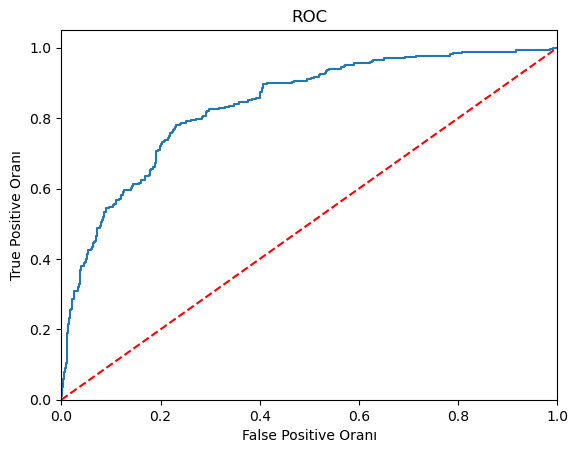

In [36]:
logit_roc_auc = roc_auc_score(y, loj_model.predict(X))

fpr, tpr, threshold = roc_curve(y, loj_model.predict_proba(X) [:, 1])
plt.figure()
plt.plot(fpr, tpr, label = 'AUC (area = %0.2f' % logit_roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Oranı')
plt.ylabel('True Positive Oranı')
plt.title('ROC')
plt.show()

*Mavi çizgi modelin başarısını değerlendirmek için kullanacağımız çizgi; Kırmızı çizgi ise hiç bir şekilde model çalışması yapmasaydık elde edeceğimiz başarıyı gösteriyor. Amacımız kırmızı çizgiden olabildiğince uzaklaşmak.*

*Bu iki çizgi arasında kalan alan yani auc, bize modelin ne kadar başarılı olduğu bilgisini verir. 0-1 arasındadır.*

In [37]:
#Validation

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.25,
                                                    random_state = 42)

In [39]:
loj = LogisticRegression(solver = 'liblinear')
loj_model = loj.fit(X_train, y_train)

In [40]:
loj_model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'liblinear',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [41]:
accuracy_score(y_test, loj_model.predict(X_test))

0.7447916666666666

In [42]:
#Dogrulanmis skora erisim

In [43]:
cross_val_score(loj_model, X_test, y_test, cv = 10).mean()

np.float64(0.7397368421052632)